In [3]:
import tensorflow as tf
from typing import TYPE_CHECKING
if TYPE_CHECKING:
    import tf_keras as keras  # v1 / v2  # LSP supported import
else:
    from tensorflow import keras  # runtime behavior
import numpy as np
import nibabel as nib
import os
import glob
import nilearn.plotting as nplt
import scipy as sp
from tqdm.notebook import tqdm
from enum import Enum
import matplotlib.pyplot as plt
import sys

DATASET_PATH = "BraTS2020_TrainingData"

class Modality(Enum):
    FLAIR = 'flair'
    T1 = 't1'
    T1CE = 't1ce'
    T2 = 't2'
    SEG = 'seg'

In [4]:
def preprocess(modality: Modality):
    """Preprocess a modality from the original dataset at DATASET_PATH

    Args:
        modality (Modality): The modality to preprocess
    """    
    # Generate list of paths to flair volumes
    vol_paths = glob.glob(os.path.join(DATASET_PATH, f"*/*/BraTS20_Training_*_{modality.value}.nii"))
    vol_paths.sort()

    for path in tqdm(vol_paths):
        vol = nib.load(path)
        data = vol.get_fdata()
        
        # z-score intensity normalisation + resizing
        if modality == Modality.SEG:
            data = sp.ndimage.zoom(data, [128 / 240] * 3, order=0)
            data[data > 0] = 1
            new_nii = nib.Nifti1Image(data.astype(np.int8), affine=vol.affine)
        else:
            data = sp.ndimage.zoom(data, [128 / 240] * 3, order=1)
            mask = data > 0.0
            mean = data[mask].mean()
            std = data[mask].std()
            data[mask] = (data[mask] - mean) / std
            data[~mask] = 0.0
            new_nii = nib.Nifti1Image(data.astype(np.float32), affine=vol.affine)
            
        nib.save(new_nii, f"training-data/{modality.value}/{path.split('/')[-1]}")

In [ ]:
preprocess(Modality.FLAIR)
preprocess(Modality.T1)
preprocess(Modality.T1CE)
preprocess(Modality.T2)
preprocess(Modality.SEG)

  0%|          | 0/369 [00:00<?, ?it/s]

In [4]:
for i in tqdm(range(1,370)):
    affine = nib.load(f"training-data/t1/BraTS20_Training_{i:03}_t1.nii").affine
    inputs = np.stack(np.array([nib.load(f"training-data/{m.value}/BraTS20_Training_{i:03}_{m.value}.nii").get_fdata(dtype=np.float32) for m in Modality if m != Modality.SEG]), axis=-1)
    inputs_img = nib.Nifti1Image(inputs.astype(np.float32), affine=affine)
    nib.save(inputs_img, f"training-data/input/BraTS20_Training_{i:03}.nii")

  0%|          | 0/369 [00:00<?, ?it/s]

In [118]:
def plot_test(i, slice_index):
    input_path = f"training-data/input/BraTS20_Training_{i+1:03}.nii"
    seg_path = f"training-data/seg/BraTS20_Training_{i+1:03}_seg.nii"
    plot_slice(nib.load(input_path), nib.load(seg_path), slice_index)
    
def plot_slice(inputs, seg, slice_index):
    input_slice: np.ndarray = inputs.get_fdata(dtype=np.float32)[:,:,slice_index,1:]
    orig = input_slice.copy()
    input_slice -= input_slice.min(axis=(0,1))
    input_slice /= input_slice.max(axis=(0,1))
    input_slice[orig == 0.0] = 0.0
    
    seg_slice = seg.get_fdata(dtype=np.float32)[:,:,slice_index]
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.imshow(input_slice)
    ax2.imshow(seg_slice)
    ax1.scatter([], [], label="T1", c='r')
    ax1.scatter([], [], label="T1ce", c='g')
    ax1.scatter([], [], label="T2", c='b')
    fig.legend(loc=[0.03,0.13])
    ax1.axis("off")
    ax2.axis("off")
    fig.tight_layout()
    fig.suptitle(f"Slice {slice_index}", y=0.86)

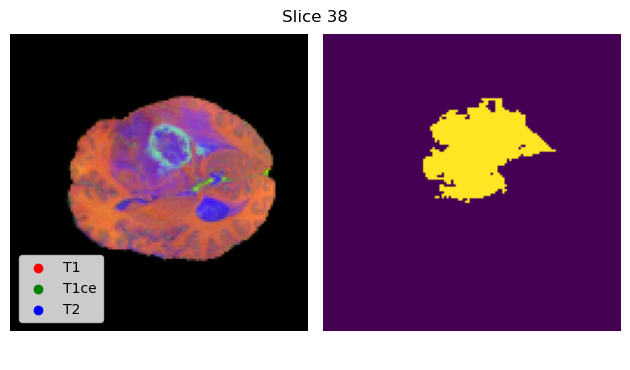

In [119]:
plot_test(0, 38)